### Exploration and visualization of Inpatient data ###

In [2]:
import pandas as pd

# Loading file data
inpatient_data = pd.read_excel('Inpatient Data.xlsx')

# Quick check
inpatient_data.head(3)

,Patient_ID,Discarge_status,CareLevel,name,sex,age,ComorbidityCount,FamilySupport,InsurancePolicy_ID,HospitalBill,RoomNumber,AdmissionSource
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,725.00,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,7128.33,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,792.50,NaN,S


In [6]:
# Standardazing column name 
inpatient_data.rename(columns={
    'Patient_ID': 'PatientID',
    'Discarge_status': 'DischargeStatus',
    'name': 'PatientName',
    'sex': 'Sex',
    'age': 'Age',
    'ComorbidityCount': 'ChronicConditionsCount',
    'FamilySupport': 'FamilySupportScore',
    'InsurancePolicy_ID': 'InsurancePolicyID' 
}, inplace=True)

# Verifying column name change
inpatient_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               891 non-null    int64  
 1   DischargeStatus         891 non-null    int64  
 2   CareLevel               891 non-null    int64  
 3   PatientName             891 non-null    object 
 4   Sex                     891 non-null    object 
 5   Age                     714 non-null    float64
 6   ChronicConditionsCount  891 non-null    int64  
 7   FamilySupportScore      891 non-null    int64  
 8   InsurancePolicyID       891 non-null    object 
 9   HospitalBill            891 non-null    float64
 10  RoomNumber              204 non-null    object 
 11  AdmissionSource         889 non-null    object 
 12  CareLevel_Desc          0 non-null      object 
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


### Plots using Seaborn ###

### Box Plot ###

### HospitalBill by CareLevel ###

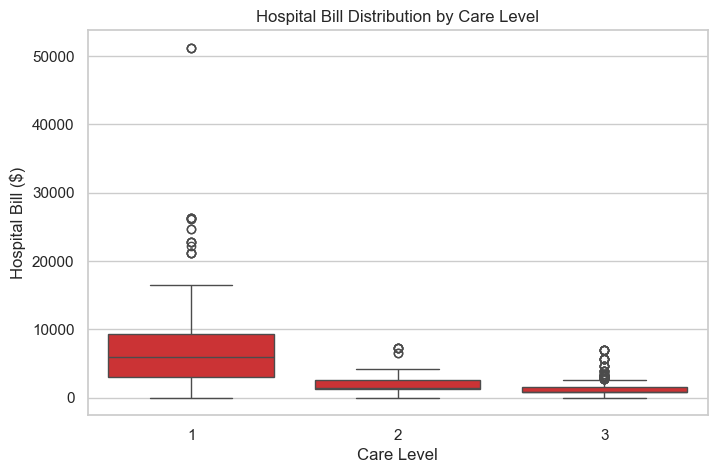

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# To set the background style as 'white grid' and color scheme  as red
sns.set(style="whitegrid", palette="Set1")

# To set the canvas size
plt.figure(figsize=(8,5))

# To Boxplot
sns.boxplot(x='CareLevel', y='HospitalBill', data=inpatient_data)

# Title
plt.title('Hospital Bill Distribution by Care Level')

# X-axis label
plt.xlabel('Care Level')

# Y-axis label
plt.ylabel('Hospital Bill ($)')

# To show the chart
plt.show()


### Inisights ###
- Advanced care levels have higher hospital bills. Patients receiving Level 1 care incur higher hospital bills.
    
- From the outliers of Care level 1, we can infer some of the advanced care level patients incur exceptionally high medical expenses like above $10,000

- The Interquartile Range (IQR) is one of the best ways to measure the spread of your data because it ignores extreme outliers. 
The spread increases with advanced care levels. So less predictable hostial bills for Care Level 1 patients. 
Generally the hospital bill is predictable, likely less than $5000 for Care Level 2 and Care Level 3 patients.
  

### Bar Plot ###

### Patients by AdmissionSource ###

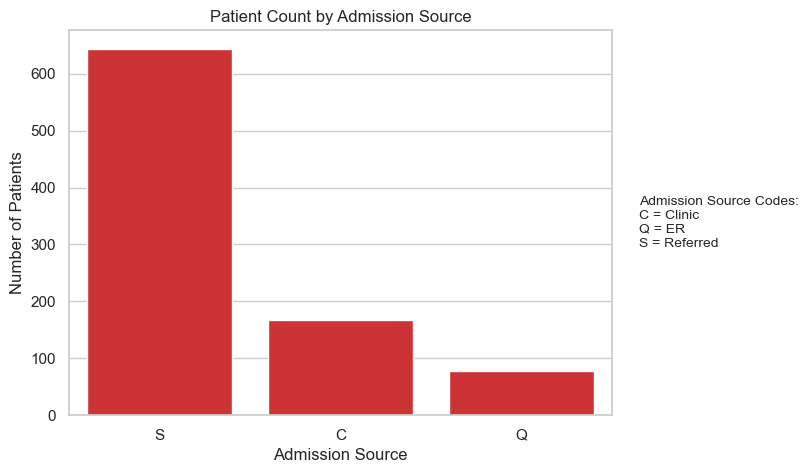

In [45]:
# To set the canvas size
plt.figure(figsize=(7,5))

# Dictionary for Admission Source
admission_map = {
    'C': 'Clinic',
    'Q': 'ER',
    'S': 'Referred'
}

# Bar plot
ax = sns.countplot(x='AdmissionSource', data=inpatient_data)

# Chat Title
plt.title('Patient Count by Admission Source')

# X-axis lebel
plt.xlabel('Admission Source')

# Y-axis lebel
plt.ylabel('Number of Patients')

# Add explanation box
legend_text = (
    "Admission Source Codes:\n"
    "C = Clinic\n"
    "Q = ER\n"
    "S = Referred"
)

plt.text(
    1.05, 0.5, legend_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='center',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# To show the plot
plt.show()

### Insights ###
- Referred patients are the domininant Category. ER patients are the least dominant category.
  
- Overall this chart helps to visualize the flow of patient trend by Admisssion Source. 
This will help hospital admiinstrators to optimize patient intake and release processes.    

### Histogram ###

### Number of chronic conditions ###

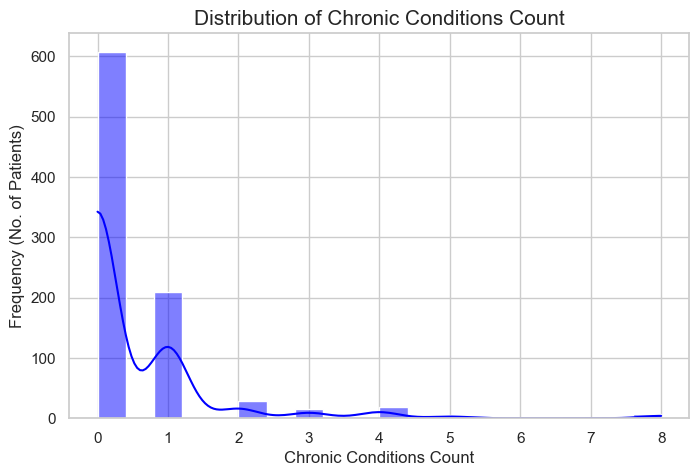

In [67]:
# To set the canvas size
plt.figure(figsize=(8, 5))

# To plot Histogram, kde=True adds the line over the bars
sns.histplot(inpatient_data['ChronicConditionsCount'], kde=True, bins=20, color="blue")

# Add labels and title for clarity
plt.title('Distribution of Chronic Conditions Count', fontsize=15)
plt.xlabel('Chronic Conditions Count', fontsize=12)
plt.ylabel('Frequency (No. of Patients)', fontsize=12)

# Show the plot
plt.show()

### Insights ###
- Its is a Right skewed ditribution. This indicates most patients have few chronic conditions like Diabetes, Hypertension, Asthma etc., and
a small minority of patients have many chronic conditions

- The mode or the highest frequency occurs at zero.Around 600 patients have zero chronic conditions. The second mode occurs at one.
Around 200 patients have atleast one chronic condition.The majority of patients are relatively healthy with 0 or 1 chronic conditions

- This also helps to spot a outlier, which occurs at 8. These are high risk patients, who require the most medical attention.

### Scatter Plot ###

### Age vs HospitalBill (Colored by CareLevel) ###

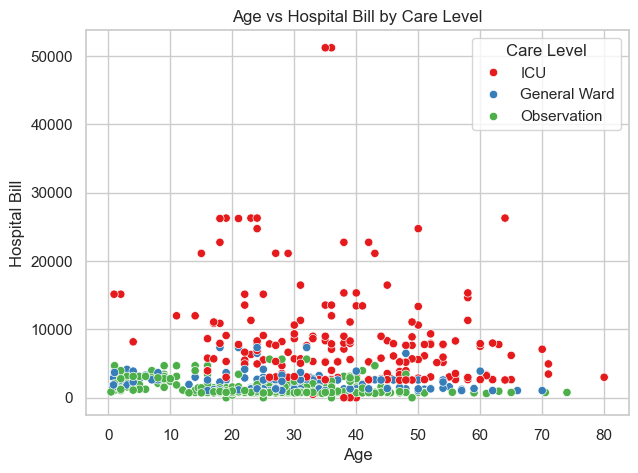

In [16]:
# Care Level Labels
care_level_labels = {
    1: 'ICU',
    2: 'General Ward',
    3: 'Observation'
}

# Care Level Desc Dataframe
inpatient_data['CareLevel_Desc'] = inpatient_data['CareLevel'].map(care_level_labels)

# To Scatter plot
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=inpatient_data,
    x='Age',
    y='HospitalBill',
    hue='CareLevel_Desc', hue_order=list(care_level_labels.values())
)

# Display
plt.title('Age vs Hospital Bill by Care Level')
plt.xlabel('Age')
plt.ylabel('Hospital Bill')
plt.legend(title='Care Level')
lt.show()

### Insights ###
- There is no strong linear relationship between Age and Hospital Bill.
  
- ICU Patient have the highest bills.Obervations patients have hte lowest bills. So Care Level is the better predictor of
Hospital Bill than Age.

- There is a very prominent outlier near Age 35, labeled as ICU with a bill exceeding $50,000. Not only Senior People and infants, across all age ICU patients are there. Also ICU costs are hightly volatile.


### Heatmap ###

### Correlation Heatmap ###

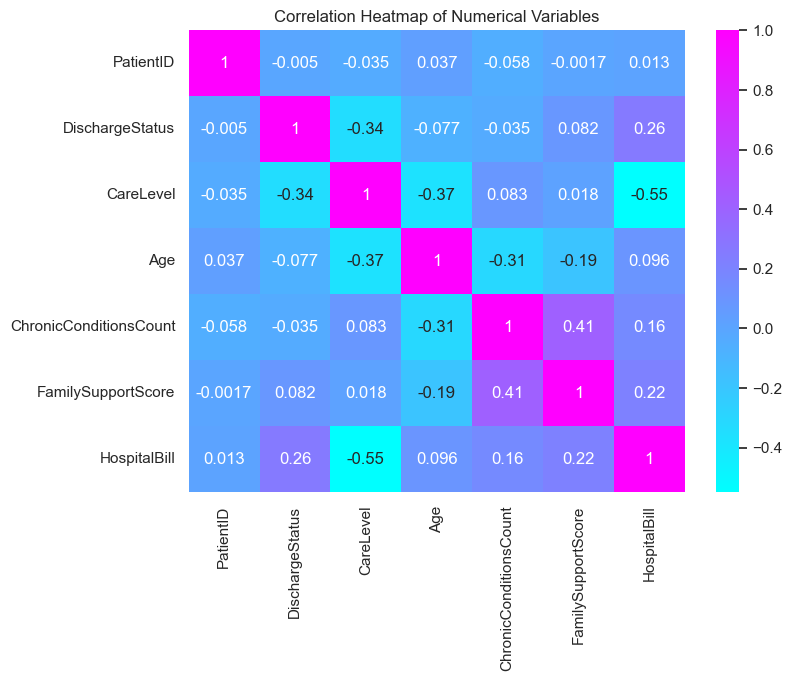

In [27]:
# To set canvas size
plt.figure(figsize=(8,6))

# Defining numeric columns
numeric_cols = ['PatientID', 'DischargeStatus', 'CareLevel', 'Age', 'ChronicConditionsCount', 'FamilySupportScore', 'HospitalBill']

# Correlation
corr = inpatient_data[numeric_cols].corr()

# To plot Heatmap
sns.heatmap(corr, annot=True, cmap='cool')

# Chart Title
plt.title('Correlation Heatmap of Numerical Variables')

# Show Chart
plt.show()

### Insights ###

- Care Level vs. Hospital Bill (-0.55) is the strongest correlation in the entire dataset. The negative value indicates that as the numerical code for CareLevel decreases (e.g., moving toward ICU), the HospitalBill increases significantly.
  
- There is a moderate positive corelation between Family Support vs. Chronic Conditions (0.41). This indicates patients with a higher number of chronic conditions tend to have higher family support scores.

- PatientID has almost zero correlation with anything. So it is an independent unique number. As seen in scatter plot, there is a week relationship between Age vs Hospital Bill(0.096). Age has almost no impact on the hospial bill.

- Age vs. Chronic Conditions (-0.31) shows that there is a slight negative correlation between age and the number of chronic conditions, which is often the opposite of general population trends.

- Hospital Bill can be best predicted from Care Lavel and Discharge Status (0.26)